# Baseline e bandits

## Importação

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Base

In [3]:
df = pd.read_parquet("../data/base_tratada.parquet")

bracos = sorted(df["braco"].unique())     
segmentos = sorted(df["tercil_idade"].unique())  

In [4]:
df.head()

,age,job,marital,education,housing,loan,contact,month,day_of_week,duration,...,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,braco,y_flag,tercil_idade
0,56,housemaid,married,basic.4y,no,no,telephone,may,mon,261,...,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,telephone_mon,0,senior
1,57,services,married,high.school,no,no,telephone,may,mon,149,...,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,telephone_mon,0,senior
2,37,services,married,high.school,yes,no,telephone,may,mon,226,...,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,telephone_mon,0,meio
3,40,admin.,married,basic.6y,no,no,telephone,may,mon,151,...,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,telephone_mon,0,meio
4,56,services,married,high.school,no,yes,telephone,may,mon,307,...,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,telephone_mon,0,senior


## Funções

In [5]:
def replay(politica, df, seed):
    df_embaralhado = df.sample(frac=1, random_state=seed).reset_index(drop=True)
    recompensas = []
    for linha in df_embaralhado.itertuples():
        segmento = linha.tercil_idade
        braco_real = linha.braco
        braco_escolhido = politica.escolher(segmento)
        if braco_escolhido == braco_real:
            recompensa = linha.y_flag
            politica.atualizar(braco_escolhido, segmento, recompensa)
            recompensas.append(recompensa)
    return recompensas

Embaralha a base com a seed, percorre linha a linha: a política escolhe um braço pro segmento daquela linha; se bater com o braço que o banco realmente usou naquela linha, a gente "aceita" o evento (atualiza a política e registra a recompensa); se não bater, descarta. 

In [6]:
freq_empirica = df["braco"].value_counts(normalize=True).reindex(bracos).values

class PoliticaHistorica:
    def __init__(self, bracos, p):
        self.bracos = bracos
        self.p = p

    def escolher(self, segmento):
        return np.random.choice(self.bracos, p=self.p)

    def atualizar(self, braco, segmento, recompensa):
        pass  


In [7]:
freq_empirica

array([0.11277557, 0.1343838 , 0.14093911, 0.12399242, 0.12265708,
       0.07725551, 0.07232689, 0.06841799, 0.07242401, 0.07482762])

In [8]:
teste = PoliticaHistorica(bracos, freq_empirica)
recompensas_teste = replay(teste, df, seed=0)
np.mean(recompensas_teste)

np.float64(0.11425233644859813)

In [9]:
class ThompsonSampling:
    def __init__(self, bracos, segmentos):
        self.bracos = bracos
        self.alpha = {s: {b: 1 for b in bracos} for s in segmentos}  # prior Beta(1,1)
        self.beta = {s: {b: 1 for b in bracos} for s in segmentos}

    def escolher(self, segmento):
        amostras = {b: np.random.beta(self.alpha[segmento][b], self.beta[segmento][b]) for b in self.bracos}
        return max(amostras, key=amostras.get)

    def atualizar(self, braco, segmento, recompensa):
        if recompensa == 1:
            self.alpha[segmento][braco] += 1
        else:
            self.beta[segmento][braco] += 1

In [10]:
class SempreOBraco:
    def __init__(self, braco_fixo):
        self.braco_fixo = braco_fixo

    def escolher(self, segmento):
        return self.braco_fixo

    def atualizar(self, braco, segmento, recompensa):
        pass

In [11]:
n_seeds = 20

def rodar_multiplas_seeds(politica_fabrica, df, n_seeds):
    resultados, n_aceitos = [], []
    for seed in range(n_seeds):
        politica = politica_fabrica()
        recompensas = replay(politica, df, seed)
        resultados.append(recompensas)
        n_aceitos.append(len(recompensas))
    return resultados, n_aceitos

In [12]:
resultados_baseline, n_aceitos_baseline = rodar_multiplas_seeds(lambda: PoliticaHistorica(bracos, freq_empirica), df, n_seeds)
resultados_ts, n_aceitos_ts = rodar_multiplas_seeds(lambda: ThompsonSampling(bracos, segmentos), df, n_seeds)
resultados_freq, n_aceitos_freq = rodar_multiplas_seeds(lambda: SempreOBraco("cellular_thu"), df, n_seeds)
resultados_teto, n_aceitos_teto = rodar_multiplas_seeds(lambda: SempreOBraco("cellular_tue"), df, n_seeds)

In [13]:
min_len = min(n_aceitos_baseline + n_aceitos_ts + n_aceitos_freq + n_aceitos_teto)

def curva_cumulativa(resultados, min_len):
    matriz = np.array([np.cumsum(r[:min_len]) / np.arange(1, min_len + 1) for r in resultados])
    media = matriz.mean(axis=0)
    erro_padrao = matriz.std(axis=0, ddof=1) / np.sqrt(matriz.shape[0])
    return media, erro_padrao

In [14]:
media_baseline, ep_baseline = curva_cumulativa(resultados_baseline, min_len)
media_ts, ep_ts = curva_cumulativa(resultados_ts, min_len)

## Resultados

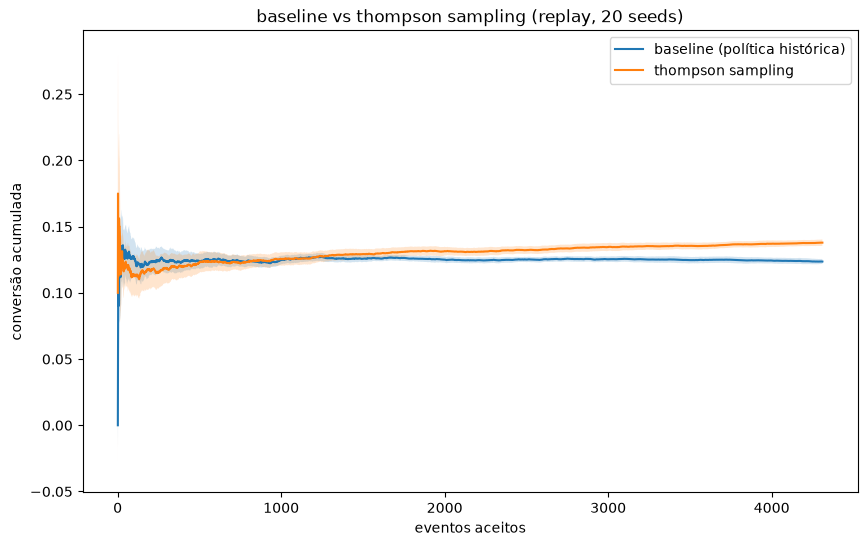

In [15]:
x = np.arange(1, min_len + 1)

plt.figure(figsize=(10, 6))
plt.plot(x, media_baseline, label="baseline (política histórica)")
plt.fill_between(x, media_baseline - 1.96*ep_baseline, media_baseline + 1.96*ep_baseline, alpha=0.2)

plt.plot(x, media_ts, label="thompson sampling")
plt.fill_between(x, media_ts - 1.96*ep_ts, media_ts + 1.96*ep_ts, alpha=0.2)

plt.xlabel("eventos aceitos")
plt.ylabel("conversão acumulada")
plt.legend()
plt.title("baseline vs thompson sampling (replay, 20 seeds)")
plt.show()

In [16]:
tabela_final = pd.DataFrame({
    "politica": ["baseline", "thompson_sampling", "sempre_cellular_thu", "melhor_braco_teto"],
    "conversao_final": [
        media_baseline[-1], media_ts[-1],
        curva_cumulativa(resultados_freq, min_len)[0][-1],
        curva_cumulativa(resultados_teto, min_len)[0][-1],
    ],
    "n_eventos_aceitos_medio": [
        np.mean(n_aceitos_baseline), np.mean(n_aceitos_ts),
        np.mean(n_aceitos_freq), np.mean(n_aceitos_teto),
    ],
})
tabela_final

,politica,conversao_final,n_eventos_aceitos_medio
0,baseline,0.123631,4457.30
1,thompson_sampling,0.137900,4735.85
2,sempre_cellular_thu,0.154234,5805.00
3,melhor_braco_teto,0.158364,5107.00


In [17]:
politica_inspecao = ThompsonSampling(bracos, segmentos)
_ = replay(politica_inspecao, df, seed=0)
pulls = {s: {b: (politica_inspecao.alpha[s][b] - 1) + (politica_inspecao.beta[s][b] - 1) for b in bracos} for s in segmentos}
pd.DataFrame(pulls)

,jovem,meio,senior
cellular_fri,321,317,213
cellular_mon,110,205,225
cellular_thu,83,514,351
cellular_tue,748,155,365
cellular_wed,266,72,132
telephone_fri,32,42,50
telephone_mon,22,28,45
telephone_thu,27,51,30
telephone_tue,43,27,45
telephone_wed,58,84,21


## Métricas

In [18]:
teto_conversao = tabela_final.loc[tabela_final["politica"] == "melhor_braco_teto", "conversao_final"].values[0]
tabela_final["regret"] = teto_conversao - tabela_final["conversao_final"]
tabela_final

,politica,conversao_final,n_eventos_aceitos_medio,regret
0,baseline,0.123631,4457.30,0.034733
1,thompson_sampling,0.137900,4735.85,0.020464
2,sempre_cellular_thu,0.154234,5805.00,0.004130
3,melhor_braco_teto,0.158364,5107.00,0.000000


A métrica de avaliação aqui é a conversão sob replay, não AUC/F1, porque a política é um bandit (decide uma ação) e não um classificador (prevê uma probabilidade fixa).

In [19]:
ganho_pp = tabela_final.loc[tabela_final["politica"]=="thompson_sampling","conversao_final"].values[0] - \
           tabela_final.loc[tabela_final["politica"]=="baseline","conversao_final"].values[0]
depositos_extra = ganho_pp * 41188
print(f"ganho: {ganho_pp*100:.1f}pp | ~{depositos_extra:.0f} depósitos adicionais por campanha")

ganho: 1.4pp | ~588 depósitos adicionais por campanha


## Golden set

In [20]:
politica_final = ThompsonSampling(bracos, segmentos)
_ = replay(politica_final, df, seed=42)  # essa é a política "definitiva" — mesma que vai pro MLflow e pra API

def recomendar(segmento, politica):
    amostras = {b: np.random.beta(politica.alpha[segmento][b], politica.beta[segmento][b]) for b in politica.bracos}
    braco = max(amostras, key=amostras.get)
    prob_estimada = politica.alpha[segmento][braco] / (politica.alpha[segmento][braco] + politica.beta[segmento][braco])
    return braco, prob_estimada

golden_set = pd.concat([
    df[df["tercil_idade"] == "jovem"].sample(2, random_state=1),
    df[df["tercil_idade"] == "meio"].sample(1, random_state=1),
    df[df["tercil_idade"] == "senior"].sample(2, random_state=1),
])[["age", "job", "education", "previous", "tercil_idade"]].reset_index(drop=True)

for i, linha in golden_set.iterrows():
    braco, prob = recomendar(linha["tercil_idade"], politica_final)
    print(f"Cliente {i}: idade={linha['age']}, job={linha['job']}, segmento={linha['tercil_idade']} -> braço={braco}, prob={prob:.3f}")

Cliente 0: idade=24, job=management, segmento=jovem -> braço=cellular_mon, prob=0.151
Cliente 1: idade=31, job=services, segmento=jovem -> braço=cellular_mon, prob=0.151
Cliente 2: idade=36, job=blue-collar, segmento=meio -> braço=cellular_fri, prob=0.136
Cliente 3: idade=55, job=admin., segmento=senior -> braço=cellular_wed, prob=0.162
Cliente 4: idade=85, job=retired, segmento=senior -> braço=cellular_tue, prob=0.141


- Clientes 0 e 1 (jovem, prob ~0,151): o canal (cellular) faz sentido — jovens convertem mais por ali em todos os tercis. Os dois caírem no mesmo dia (segunda) reforça que a recomendação é por segmento, não por perfil individual; não atribuiria isso a hábito de trabalho, porque job não é usado no cálculo e a diferença entre dias dentro do cellular é pequena diante do tamanho da amostra.
- Cliente 2 (meio, prob 0,136): o canal faz sentido, mas repare que a probabilidade é a mais baixa dos cinco — bate com o achado da EDA de que o tercil "meio" (35-44 anos) converte sistematicamente menos que jovem e senior, em qualquer braço.
- Clientes 3 e 4 (senior, prob 0,162 e 0,141): mesmo raciocínio dos jovens — canal correto, dia não é um padrão de comportamento sênior, é a amostra da Beta daquela chamada específica. Os dois ficarem em dias diferentes é esperado, não uma falha.